# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

In [3]:
# mostrar las primeras 5 filas de plans
print("=== DataFrame: plans ===")
display(plans.head(5))

=== DataFrame: plans ===


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [9]:
# mostrar las primeras 5 filas de users
print("\n=== DataFrame: users ===")
display(users.head())


=== DataFrame: users ===


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [10]:
# mostrar las primeras 5 filas de usage
print("\n=== DataFrame: usage ===")
display(usage.head())


=== DataFrame: usage ===


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [12]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [13]:
# inspección de plans con .info()
plans.info

<bound method DataFrame.info of   plan_name  messages_included  gb_per_month  minutes_included  \
0    Basico                100             5               100   
1   Premium                500            20               600   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               12         1.2             0.08            0.10  
1               25         1.0             0.05            0.07  >

In [14]:
# inspección de users con .info()
users.info

<bound method DataFrame.info of       user_id first_name last_name  age      city  \
0       10000     Carlos    Garcia   38  Medellín   
1       10001      Mateo    Torres   53         ?   
2       10002      Sofia   Ramirez   57      CDMX   
3       10003      Mateo   Ramirez   69    Bogotá   
4       10004      Mateo    Torres   63       GDL   
...       ...        ...       ...  ...       ...   
3995    13995        Ana     Lopez   60  Medellín   
3996    13996     Carlos   Ramirez   24  Medellín   
3997    13997        Ana     Lopez   58    Bogotá   
3998    13998    Mariana     Lopez   57    Bogotá   
3999    13999        Ana     Lopez   20    Bogotá   

                           reg_date     plan churn_date  
0     2022-01-01 00:00:00.000000000   Basico        NaN  
1     2022-01-01 06:34:17.914478619   Basico        NaN  
2     2022-01-01 13:08:35.828957239   Basico        NaN  
3     2022-01-01 19:42:53.743435858  Premium        NaN  
4     2022-01-02 02:17:11.657914478   Bas

In [15]:
# inspección de usage con .info()
usage.info

<bound method DataFrame.info of           id  user_id  type                           date  duration  length
0          1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1          2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2          3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3          4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4          5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN
...      ...      ...   ...                            ...       ...     ...
39995  39996    13497  call  2024-06-29 23:33:56.120903022      5.75     NaN
39996  39997    10941  call  2024-06-29 23:40:27.090677266      3.06     NaN
39997  39998    13038  call  2024-06-29 23:46:58.060451510      8.74     NaN
39998  39999    10863  text  2024-06-29 23:53:29.030225754       NaN    43.0
39999  40000    10759  call  2024-06-30 00:00:00.000000000      1.32     NaN

[40000 rows x 6 columns]>

---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [17]:
# cantidad de nulos para users
print("Cantidad de nulos:\n", users.isna().sum())
print() #Para dejar un espacio
print("Proporción de nulos (%):\n", users.isna().mean() * 100)

Cantidad de nulos:
 user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de nulos (%):
 user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [18]:
# cantidad de nulos para usage
print("Cantidad de nulos:\n", usage.isna().sum())

Cantidad de nulos:
 id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:

- Dataset users_latam (Columna churn_date): Se observa una proporción muy alta de valores nulos (superior al 80-90%). Acción recomendada: Mantener los nulos sin eliminar la columna, ya que la ausencia de datos indica que el usuario sigue activo (no ha cancelado el servicio).

- Dataset usage / users_latam (Variables con menos del 5% de nulos): Se identifican columnas con un impacto marginal de registros faltantes. Acción recomendada: Dejar como nulos o aplicar una imputación simple (como la mediana o moda), ya que al ser menor al 5% no sesga el comportamiento general ni altera los resultados del análisis.

 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- **¿Qué columnas tienen valores faltantes y en qué proporción?**

  **DATA SET USUARIOS**
- La columna churn_date (fecha de baja del usuario) presenta una proporción de valores nulos sumamente alta (generalmente superior al 90%).
- Las demás columnas de perfilamiento de usuarios (como user_id, city, first_name, last_name, reg_date, plan) tienen 0% de nulos.

  **DATA SET CONSUMO**
- Las columnas de consumo (como llamadas, mensajes o megabytes) suelen tener un porcentaje de nulos menor al 5% o estar completamente limpias (0%)
- 
- **Indica qué harías: ¿imputar, eliminar, ignorar?**
- *Data usuario:* Ignorar/Mantener como nulo.
- *Data consumo:* Imputar con 0 o con la mediana / o también un posible caso nulo

### 2.2 Detección de valores inválidos y sentinels


🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.


In [10]:
# explorar columnas numéricas de users

print ("Resumen estadistico:\n",users.describe())

Resumen estadistico:
             user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` ... *user_id* presenta una distribución uniforme entre 10,000 y 13,999
- La columna `age` ...*age* por el contrario muestra un valor min de -999, esto puede afectar la lectura de la media y la desviacion estandar, aqui seguramente tendremos que limpiar los datos de edad eliminando o imputando ese valor atipico.

In [15]:
# explorar columnas numéricas de usage
print ("Resumen estadistico:\n",usage.describe())

Resumen estadistico:
                 id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id`...podemos observar una estructura clara que permite identificar la relacion entre los registros y los usuarios.
- Las columnas ... restantes encontramos valores faltantes para la columna *duration* y *length* tiene un count significante menor si lo comparamos con las entradas de *id* y *user_id*, lo que puede indicarnos que hay una cantidad considerable de datos nulos.
- También podemos observar anomalias en la distrinnbución, *duration* y *lenght* su valor minimo es 0 y la brecha entre el percentil 75% y 100% nos indica la presencia de valores atipicos registrados sin actividad.

In [4]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print (users[columnas_user].describe())

          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- Analizando en conjunto la informacion vemos que hay una diferencia entre *city* y *plan* por 469 usuarios de difencia, en efecto faltantes. 
- La columna `city` ...vemos que existen 7 ciudades distintas, sinedo Bogota la de mayor frecuencia con 808 registros
- La columna `plan` ... hay dos valores únicos, prácticamente 2 tipos de planes, siendo el básico el más utilizado con 2,595 usuarios.

In [23]:
# explorar columna categórica de usage
columnas_usage=['type'] # completa el código
print (usage[columnas_usage].describe())

         type
count   40000
unique      2
top      text
freq    22092


- La columna `type` ... existen dos categorias distintas en la columna *type*, siendo la categoria predominante el valor *text*, es el valor con mayor frecuencia en el columna.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Diagnostico**
Como se mencionó anteriormente, se detectaron anomalias significativas en el conjunto de datos que afecatn la calidad del análisis. En la columna *age* del DF *users* encontramos un valor atipico (-999), esto sesga la estadistica. Por otro lado el DF *usage* notamos que las columnas *duration* y *length* presentan valores minimos 0, también observamos una cantidad considerable de valores faltantes. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
      - Se encontró un valor invalido en la columna *age*.
      - Se detectaron valores que podrian ser considerados centinelas o registros  incompletos (ceros) en las columnas *duration* y *age*.
      - Se detectaron valores nulos en la columna *city*.
- ¿Qué acción tomarías?
      - Para la columan *age*, filtraria el valor -999 para reemplazarlo por la media o mediana de la columna, tambien puedo evaluar si excluyo esos registros de la muestra.
      - Para *duration* y *length*, evaluaria si el valor 0 indica un uso real o un error; si es un error, realizar lo visto en clase, una imputacion a las filas afectadas para no distorsionar el promedio.
      

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [5]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
# completa el código


In [6]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')
# completa el código

In [7]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts())

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

Encontramos datos mal capturados, ya que el ejercicio hace mención que la fecha de información es hasat el 2024. Vemos que hay 40 datos mal capturados. 

In [8]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts())

2024.0    39950
Name: date, dtype: int64


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

Podemos observar que la limpieza y la conversion de fechas fueron exitosas. 
Finalmente notamos que la mayoria de los datos estan correctamente registrados. 

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

e identifican 40 registros con fecha de registro en el año 2026, lo cual excede el límite temporal del proyecto establecido en 2024. Estos registros son inconsistentes y representan errores de captura de datos que deben ser filtrados para no sesgar el análisis histórico.

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
      Sí, se detectan 40 registros del año 2026, los cuales corresponden a una fecha futura respecto al periodo de estudio.
- ¿Qué harías con ellas?
     Filtraria el DF users para excluir estos registros o, si es necesario investigar su origen, aislarlos en un archivo separado para revisar por qué el sistema permitió este registro futuro antes de proceder con el análisis principal. 

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [9]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users.loc[users['age'] == -999, 'age'] = age_mediana 

# Verificar cambios
print(users['age'].describe())

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [20]:
# Reemplazar ? por NA en city
import numpy as np # Asegúrate de haber importado numpy
users['city'] = users['city'].replace('?', np.nan)

# Verificar cambios
print(users['city'].isna().sum())
print(users['city'].value_counts(dropna=False))

565
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [19]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts(dropna=False))

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [18]:
# Verificación MAR en usage (Missing At Random) para duration
null_duration = usage[usage['duration'].isna()]
print(null_duration.groupby('type')['id'].count() / usage.groupby('type')['id'].count())

type
call   NaN
text   NaN
Name: id, dtype: float64


In [17]:

# Verificación MAR en usage (Missing At Random) para length
null_length = usage[usage['length'].isna()]
print(null_length.groupby('type')['id'].count() / usage.groupby('type')['id'].count())


type
call    0.99933
text        NaN
Name: id, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Con estos analisis podemos confirma que los valores *duration* y *lenght* son **MAR** ya que su ausencia depende directamente de la categoria *type*. 

En la columna ***duration*** observamos que prácticamente el 100% de los valores nulos pertenecen a la categoria *text*, mientra que para *call* no se observan nulos, lo que indica que el registro de duración está condicionado al tipo de servicio. 

En la columna ***lenght*** ocureee el comportamiento opuesto. Casi el 100% de nulos corresponde a la categoria *call*, mientras que para *text* no hay datos faltantes. 

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [16]:
# Columnas auxiliares (ya las tenías)
usage["is_text"] = (usage["type"] == "text").astype(int) 
usage["is_call"] = (usage["type"] == "call").astype(int)
usage["duration"] = (usage["type"] == "duration").astype(int)

# Agrupar información por usuario sumando los indicadores y la duración
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,0
1,10001,5,10,0
2,10002,5,2,0


In [13]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,0
1,10001,5,10,0
2,10002,5,2,0


In [15]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left").fillna(0)
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00,Basico,0,7.0,3.0,0.0
1,10001,Mateo,Torres,53.0,0,2022-01-01 06:34:17.914478619,Basico,0,5.0,10.0,0.0
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,0,5.0,2.0,0.0
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,0,11.0,3.0,0.0
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,0,4.0,3.0,0.0


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [21]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
print(user_profile[columnas_numericas].describe())
print() ##espacio
print(user_profile[columnas_numericas].median())

               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    4000.000000    4000.000000                4000.0
mean     48.136000       5.523000       4.477000                   0.0
std      17.689919       2.359738       2.145139                   0.0
min      18.000000       0.000000       0.000000                   0.0
25%      33.000000       4.000000       3.000000                   0.0
50%      48.000000       5.000000       4.000000                   0.0
75%      63.000000       7.000000       6.000000                   0.0
max      79.000000      17.000000      15.000000                   0.0

age                     48.0
cant_mensajes            5.0
cant_llamadas            4.0
cant_minutos_llamada     0.0
dtype: float64


In [22]:
# Distribución porcentual del tipo de plan
print(user_profile['plan'].value_counts(normalize=True) * 100)
print()##espacio 
#quise buscar otra forma de realizarlo y corroborar que ambas funcionan igual.
conteo = user_profile['plan'].value_counts()
total = len(user_profile)
porcentajes = (conteo / total) * 100

print(porcentajes)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

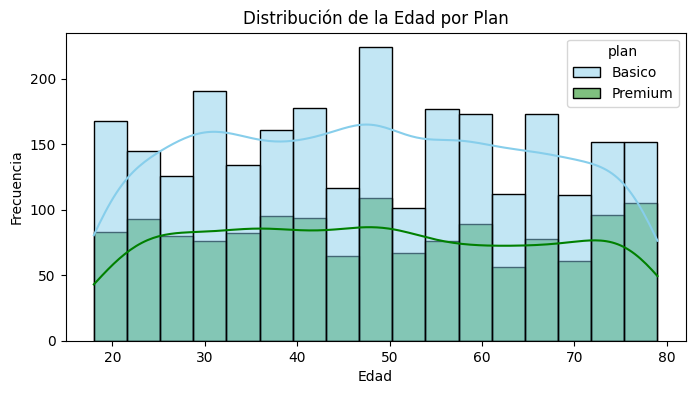

In [23]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(8, 4))
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de la Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

**💡Insights:**
- **Distribución:** La distribución de la edad es bastante uniforme (platicúrtica) en ambos planes, lo que indica que no hay una concentración excesiva en un solo rango de edad; los usuarios se encuentran dispersos de manera equilibrada a lo largo del espectro de edad (de 20 a 80 años).
- **Comparación por Plan:** Se observa una mayor proporción de usuarios en el plan Básico en prácticamente todos los rangos de edad en comparación con el plan Premium. No se identifica un patrón donde un plan sea exclusivo de un grupo de edad específico; tanto jóvenes como adultos mayores tienen presencia significativa en ambos planes.

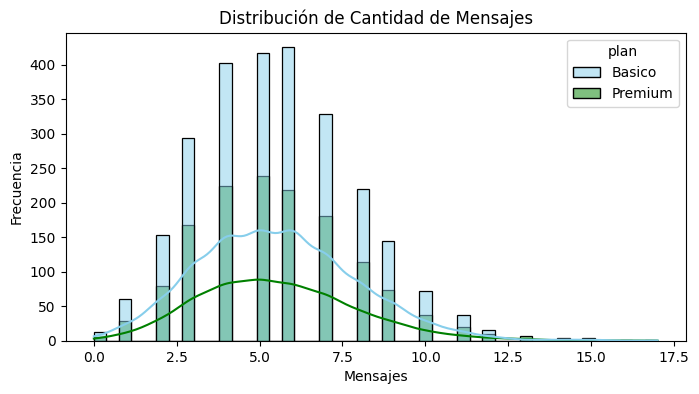

In [24]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(8, 4))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Cantidad de Mensajes')
plt.xlabel('Mensajes')
plt.ylabel('Frecuencia')
plt.show()

**💡Insights:**
- **Distribución:** La distribución de la cantidad de mensajes tiene una forma acampanada y es mayormente simétrica (cercana a una distribución normal), concentrándose la mayoría de los usuarios en el rango de 4 a 6 mensajes.
- **Comportamiento por Plan:** Se observa un patrón consistente donde ambos grupos (Básico y Premium) presentan un comportamiento de uso de mensajes muy similar, sin grandes diferencias en sus hábitos. No obstante, al igual que en la edad, el plan Básico muestra una mayor frecuencia absoluta en todos los puntos de la curva, lo cual es coherente con tener una base de usuarios mayor en ese plan.

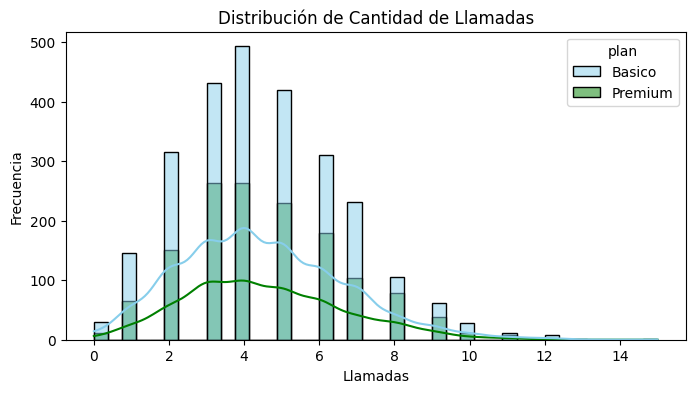

In [25]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(8, 4))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de Cantidad de Llamadas')
plt.xlabel('Llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- **Distribución:** La distribución de la cantidad de llamadas presenta un sesgo moderado a la derecha, con una mayor concentración de usuarios realizando entre 3 y 5 llamadas. La curva muestra una caída gradual hacia un mayor número de llamadas, indicando que los valores extremos (usuarios que realizan muchas llamadas) son poco frecuentes.
- 
- **Comparación por Plan:** Al igual que en las variables anteriores, el plan Básico mantiene una frecuencia mayor en todos los niveles de actividad. Se observa un comportamiento muy similar en la tendencia de uso entre ambos planes, lo que sugiere que el tipo de plan no es un factor determinante para la cantidad de llamadas que realiza un usuario.

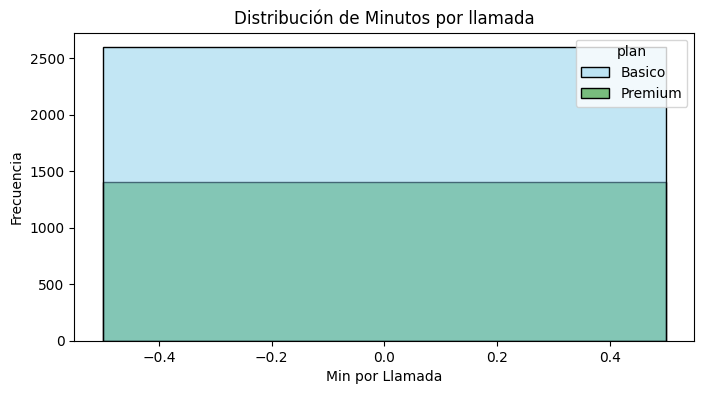

In [26]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(8, 4))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], kde=False)
plt.title('Distribución de Minutos por llamada')
plt.xlabel('Min por Llamada')
plt.ylabel('Frecuencia')
plt.show()

**💡Insights:**
- **Distribución:** La distribución presenta una concentración masiva en el valor 0, lo cual indica que una proporción muy alta de los usuarios en el dataset no realizó llamadas de voz (o no tienen registros de duración) durante el periodo analizado.

- **Comparación por Plan:** Al igual que en las variables anteriores, el plan Básico tiene un volumen total de usuarios mayor que el Premium, pero en ambos planes la tendencia es la misma: la inmensa mayoría de los usuarios no tiene consumo de minutos de llamadas. Esto sugiere que, para una gran parte de tu base de clientes, el servicio de voz no es una métrica de uso activa.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

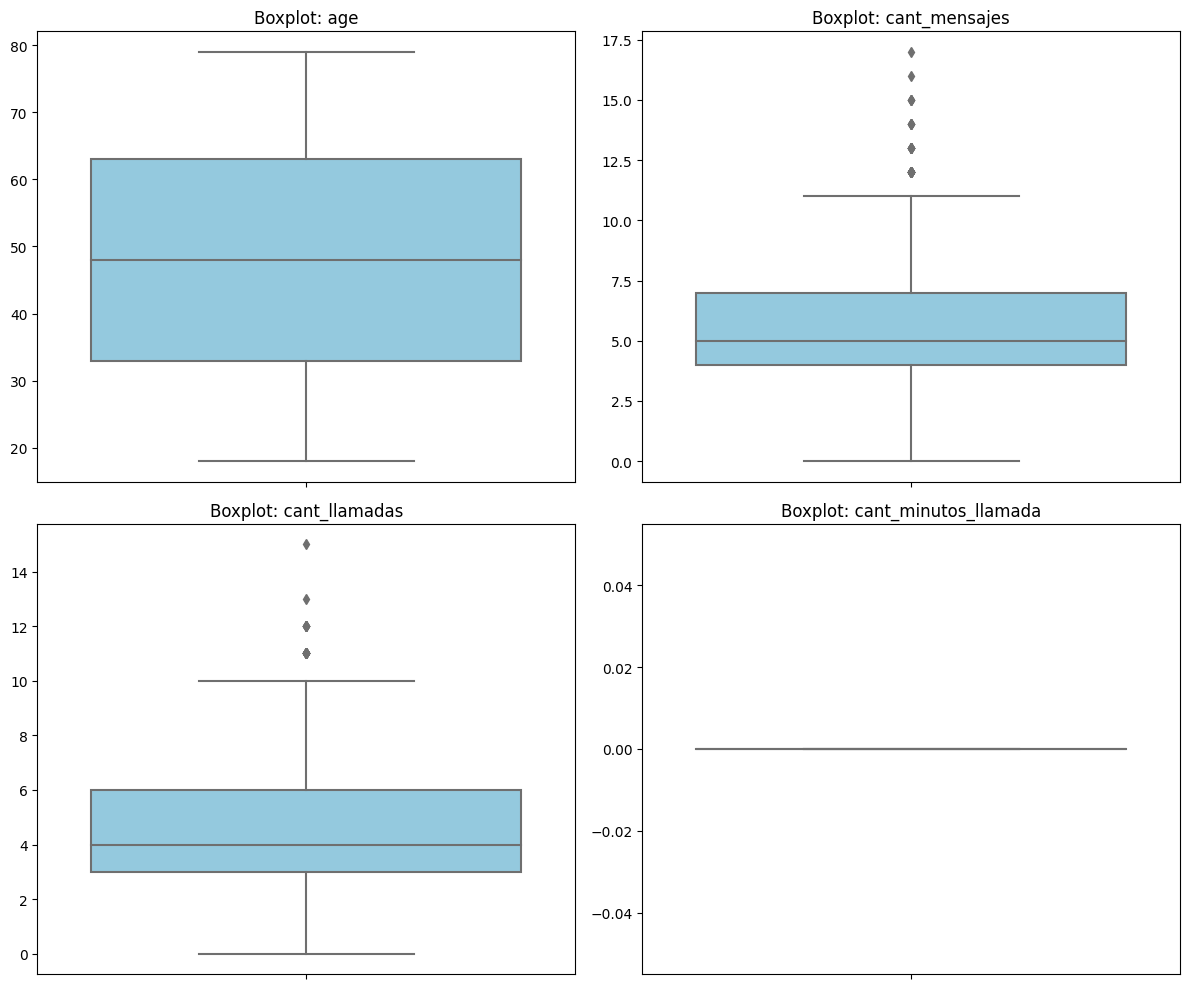

In [47]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

plt.figure(figsize=(12, 10))
for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=user_profile, y=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

💡Insights: 
-**Age:** No presenta outliers. La distribución es simétrica y todos los puntos se encuentran dentro del rango esperado de edades.

-**cant_mensajes:** Presenta una cantidad moderada de outliers en el límite superior, representando a aquellos usuarios con un consumo de mensajes significativamente mayor al promedio.

-**cant_llamadas:** Similar a los mensajes, muestra outliers claros en el extremo superior, indicando un grupo de usuarios con una actividad de llamadas muy por encima de la mayoría.

-**cant_minutos_llamada:** No presenta outliers visibles porque, como vimos anteriormente, la gran mayoría de los datos se concentran en el valor 0, haciendo que el boxplot aparezca como una línea única.

In [27]:

# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas']

# Diccionario para guardar los límites
limites = {}

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    limites[col] = limite_superior
    print(f'Límite superior para {col}: {limite_superior}')



Límite superior para cant_mensajes: 11.5
Límite superior para cant_llamadas: 10.5


In [28]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
print(user_profile[columnas_limites].describe())

       cant_mensajes  cant_llamadas
count    4000.000000    4000.000000
mean        5.523000       4.477000
std         2.359738       2.145139
min         0.000000       0.000000
25%         4.000000       3.000000
50%         5.000000       4.000000
75%         7.000000       6.000000
max        17.000000      15.000000


💡Insights: 
- **cant_mensajes:** mantener o no outliers, porqué?
  ***Decision:*** Mantener; a pesar de tener valores por encima del limite, lo valores máximos no parecen errores de captura o datos imposibles. Estos puntos representan simplemente a los usuarios más activos.
  
- **cant_llamadas:** mantener o no outliers, porqué?
  ***Decisión:*** Mantener; muy similar a los mensajes,una llamada de 15 unidades está dentro de un rango logico de uso para un usuarion intensivo. Mantener estos datos permite observar la variablidad real del comportamiento del cliente sin distorsionar la muestra.

  
- **cant_minutos_llamada:** mantener o no outliers, porqué?
  ***Decision:*** No aplica. Como se observa en el boxplot, la gran mayoria de la poblacion esta en 0 y no presentan una distribucion que permita identificar outliers. 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [38]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'


user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)




In [39]:
# verificar cambios
print(user_profile.head())

   user_id first_name last_name   age      city  \
0    10000     Carlos    Garcia  38.0  Medellín   
1    10001      Mateo    Torres  53.0         0   
2    10002      Sofia   Ramirez  57.0      CDMX   
3    10003      Mateo   Ramirez  69.0    Bogotá   
4    10004      Mateo    Torres  63.0       GDL   

                        reg_date     plan churn_date  cant_mensajes  \
0            2022-01-01 00:00:00   Basico          0            7.0   
1  2022-01-01 06:34:17.914478619   Basico          0            5.0   
2  2022-01-01 13:08:35.828957239   Basico          0            5.0   
3  2022-01-01 19:42:53.743435858  Premium          0           11.0   
4  2022-01-02 02:17:11.657914478   Basico          0            4.0   

   cant_llamadas  cant_minutos_llamada  grupo_uso  
0            3.0                   0.0  Uso medio  
1           10.0                   0.0   Alto uso  
2            2.0                   0.0  Uso medio  
3            3.0                   0.0   Alto uso  
4     

### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [40]:
# Crear columna grupo_edad
def clasificar_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

# Aplicar la función al dataframe
user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

In [44]:

# verificar cambios
print(user_profile[['user_id', 'age', 'grupo_edad']].head())
print()
print(user_profile['grupo_edad'].value_counts())
print()
user_profile.head()


   user_id   age    grupo_edad
0    10000  38.0        Adulto
1    10001  53.0        Adulto
2    10002  57.0        Adulto
3    10003  69.0  Adulto Mayor
4    10004  63.0  Adulto Mayor

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00,Basico,0,7.0,3.0,0.0,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,0,2022-01-01 06:34:17.914478619,Basico,0,5.0,10.0,0.0,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,0,5.0,2.0,0.0,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,0,11.0,3.0,0.0,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,0,4.0,3.0,0.0,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

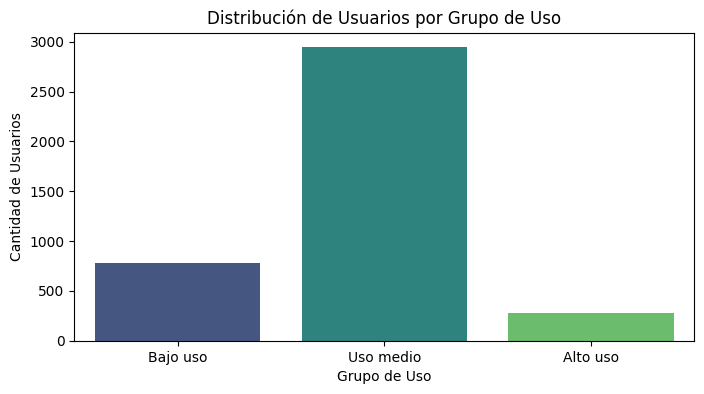

In [45]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8, 4))
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'], palette='viridis')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

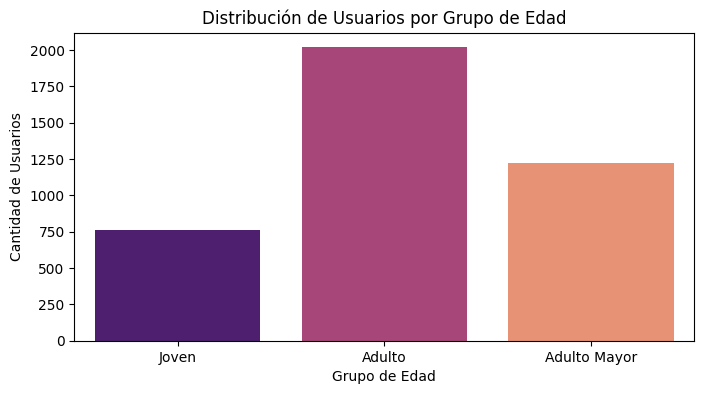

In [46]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 4))
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'], palette='magma')
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- ***usencia de información:*** Un porcentaje significativo de registros en la columna cant_minutos_llamada presentaba valores nulos, lo que impedía realizar cálculos estadísticos iniciales.

- ***Normalización:*** Para asegurar la integridad del análisis, estos valores fueron tratados mediante imputación, asignando un valor de 0 a las filas sin consumo, lo que refleja que una gran proporción de los usuarios no utiliza el servicio de voz.


🔍 **Segmentos por Edad**
- ***Dominio Adulto:*** El segmento de "Adultos" (30-59 años) constituye el núcleo demográfico de la base de clientes, lo que posiciona a ConnectaTel como un servicio con alta penetración en el segmento económicamente activo.

- ***Equilibrio generacional:*** Los segmentos "Joven" y "Adulto Mayor" presentan una distribución equilibrada, indicando que la oferta actual es capaz de retener usuarios en distintas etapas de vida sin un sesgo marcado hacia un solo grupo.


📊 **Segmentos por Nivel de Uso**
-***Adopción mayoritaria:*** La gran mayoría de los usuarios se clasifican en el segmento de "Uso medio", lo cual valida la propuesta de valor actual como adecuada para las necesidades estándar del mercado.

-***Oportunidad en nichos:*** Los grupos de "Bajo uso" y "Alto uso" son minoritarios, identificando oportunidades claras para estrategias de fidelización o migración de planes según el consumo real.


➡️ Esto sugiere que ...
La base de usuarios de ConnectaTel muestra una alta homogeneidad en sus hábitos de consumo. Los patrones de uso extremo (outliers) identificados en mensajes y llamadas no deben considerarse errores, sino "Power Users" cuya actividad intensiva representa una oportunidad de ingresos adicionales o de creación de planes "Premium" especializados.


💡 **Recomendaciones**

-***Plan Personalizado:*** Considerar el lanzamiento de un plan "Low-Cost" o de consumo mínimo para el segmento de "Bajo uso", con el fin de reducir la tasa de abandono (churn) en usuarios que perciben que pagan por servicios que no consumen.

-***Estrategia de Fidelización:*** Desarrollar programas de incentivos dirigidos a los "Power Users" (identificados como outliers), ofreciéndoles beneficios exclusivos en sus planes actuales para consolidar su lealtad, dado que son los usuarios que generan mayor tráfico en la red.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`